# Digital Twin — QoSBuddy Innovation #2 (v3)
**NS-3 LENA Gymnasium Environment · Member 4**

Uses the **exact same 14-column dataset** produced by `ns3_lena_collector_v5`:
```
timestamp, ue_id, sinr_dl_db, mcs_dl, throughput_mbps, delay_ms, jitter_ms,
packet_loss_ratio, prb_utilization, retransmissions, cqi,
load_level, mobility_speed, shadowing_enabled
```

| Step | What happens |
|---|---|
| **1** | Load & clean the NS-3 LENA dataset |
| **2** | Build `QoSNetworkEnv` — a Gymnasium env backed by real NS-3 rows |
| **3** | Smoke-test with a random agent |
| **4** | Export `QoSNetworkEnv.py` → handoff to M1 (PPO RL training) |

---
## 1. Imports

In [10]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
warnings.filterwarnings('ignore')
np.random.seed(42)
subprocess.run('pip install gymnasium -q', shell=True, capture_output=True)
import gymnasium as gym
from gymnasium import spaces
print('Imports OK')

Imports OK


---
## 2. Mount Drive & Load NS-3 LENA Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/5g_dataset2.csv'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = '/content/5g_dataset2.csv'

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at {DATASET_PATH}.\n'
    'Run ns3_lena_collector_v5 first to generate the data.'
)

EXPECTED_COLS = [
    'timestamp','ue_id','sinr_dl_db','mcs_dl','throughput_mbps',
    'delay_ms','jitter_ms','packet_loss_ratio','prb_utilization',
    'retransmissions','cqi','load_level','mobility_speed','shadowing_enabled'
]

df_raw = pd.read_csv(DATASET_PATH)
missing = set(EXPECTED_COLS) - set(df_raw.columns)
assert len(missing) == 0, f'Missing columns: {missing}'

print(f'Loaded : {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded : (32525, 14)
Columns: ['timestamp', 'ue_id', 'sinr_dl_db', 'mcs_dl', 'throughput_mbps', 'delay_ms', 'jitter_ms', 'packet_loss_ratio', 'prb_utilization', 'retransmissions', 'cqi', 'load_level', 'mobility_speed', 'shadowing_enabled']


,timestamp,ue_id,sinr_dl_db,mcs_dl,throughput_mbps,delay_ms,jitter_ms,packet_loss_ratio,prb_utilization,retransmissions,cqi,load_level,mobility_speed,shadowing_enabled
0,1,1,-20.51350,0,0.058944,268.886,4.16667,0.970,4,283,0,1,0,0
1,2,1,-5.82407,0,0.481376,135.327,6.69679,0.755,6,1,0,1,0,0
2,3,1,-12.05090,0,0.275072,241.141,25.89800,0.860,3,271,0,1,0,0


---
## 3. Data Cleaning
Same pipeline as DSO2.1 — must be consistent.

In [12]:
df = df_raw.copy()
print(f'Rows before cleaning: {len(df):,}')

df = df.drop_duplicates()

INT_COLS   = ['timestamp','ue_id','mcs_dl','prb_utilization',
              'retransmissions','cqi','load_level','mobility_speed','shadowing_enabled']
FLOAT_COLS = ['sinr_dl_db','throughput_mbps','delay_ms','jitter_ms','packet_loss_ratio']
for c in INT_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
for c in FLOAT_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna()
for c in INT_COLS:
    df[c] = df[c].astype(int)

RULES = {
    'sinr_dl_db': (-50, 90), 'mcs_dl': (0, 28),
    'throughput_mbps': (0, 100), 'delay_ms': (0, 5000),
    'jitter_ms': (0, 2000), 'packet_loss_ratio': (0, 1),
    'prb_utilization': (0, 100), 'retransmissions': (0, 9999),
    'cqi': (1, 15), 'load_level': (1, 3),
    'mobility_speed': (0, 3), 'shadowing_enabled': (0, 1),
}
mask = pd.Series(True, index=df.index)
for col, (lo, hi) in RULES.items():
    bad = (df[col] < lo) | (df[col] > hi)
    if bad.sum():
        print(f'  Out-of-range [{col}]: {bad.sum():,} rows')
    mask &= ~bad
df = df[mask].reset_index(drop=True)

warmup = (df['throughput_mbps'] == 0) & (df['delay_ms'] == 0)
df = df[~warmup].reset_index(drop=True)

for col in ['throughput_mbps', 'delay_ms', 'jitter_ms', 'sinr_dl_db']:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

df = df.sort_values(['ue_id', 'timestamp']).reset_index(drop=True)

print(f'Rows after cleaning : {len(df):,}')
print(f'UEs                 : {df["ue_id"].nunique()}')
print(f'Load levels         : {sorted(df["load_level"].unique())}')
print(f'Mobility configs    : {sorted(df["mobility_speed"].unique())}')
display(df[FLOAT_COLS].describe().round(3))

Rows before cleaning: 32,525
  Out-of-range [sinr_dl_db]: 531 rows
  Out-of-range [delay_ms]: 18 rows
  Out-of-range [cqi]: 11,926 rows
  Out-of-range [load_level]: 3,810 rows
  Out-of-range [mobility_speed]: 295 rows
Rows after cleaning : 18,580
UEs                 : 5
Load levels         : [np.int64(1), np.int64(2), np.int64(3)]
Mobility configs    : [np.int64(0), np.int64(1), np.int64(3)]


,sinr_dl_db,throughput_mbps,delay_ms,jitter_ms,packet_loss_ratio
count,18580.000,18580.000,18580.000,18580.000,18580.000
mean,15.817,4.641,32.343,5.675,0.112
std,12.115,2.489,33.173,4.915,0.210
min,-4.421,0.344,1.622,0.445,0.000
25%,8.466,2.417,13.278,2.593,0.020
50%,14.709,4.379,26.853,4.986,0.045
75%,22.543,6.948,40.416,7.664,0.069
max,85.964,9.008,233.585,36.966,0.998


---
## 4. Build `QoSNetworkEnv` (Gymnasium)

### Observation space (8 features from the 14 NS-3 columns)
```
[sinr_dl_db, throughput_mbps, delay_ms, jitter_ms,
 packet_loss_ratio, prb_utilization, retransmissions, sla_risk_score]
```

### Action space (4 discrete actions)
```
0 = reroute      → +SINR, -delay
1 = throttle     → -loss,  -throughput
2 = prioritize   → +SINR, +throughput, -jitter  (best for URLLC)
3 = no_action    → slight passive degradation
```

### Reward
```
-1.0 per SLA violation + 0.3 * risk_reduction + 0.05 proactive_bonus
```

In [13]:
env_py = 'import gymnasium as gym\nimport numpy as np\nimport pandas as pd\nimport os\nfrom gymnasium import spaces\n\n\nclass QoSNetworkEnv(gym.Env):\n    """\n    Digital Twin Gymnasium environment backed by real NS-3 LENA data.\n\n    Observation (8 floats):\n        [sinr_dl_db, throughput_mbps, delay_ms, jitter_ms,\n         packet_loss_ratio, prb_utilization, retransmissions, sla_risk_score]\n\n    Actions (Discrete 4):\n        0=reroute  1=throttle  2=prioritize  3=no_action\n\n    Reward:\n        -1.0 per SLA violation\n        +0.3 * risk_reduction vs previous step\n        +0.05 proactive bonus (action taken, no violation)\n    """\n    metadata = {"render_modes": ["human"]}\n    ACTION_NAMES = {0: "reroute", 1: "throttle", 2: "prioritize", 3: "no_action"}\n\n    SLA = {\n        1: {"sinr": -25.0, "delay": 300.0, "loss": 0.80, "tput": 0.01},\n        2: {"sinr": -18.0, "delay": 200.0, "loss": 0.60, "tput": 0.05},\n        3: {"sinr": -10.0, "delay": 120.0, "loss": 0.30, "tput": 0.20},\n    }\n\n    ACTION_FX = {\n        0: {"sinr": +4.0,  "delay": 0.75, "loss": 0.70, "tput": 1.10},\n        1: {"sinr": +0.0,  "delay": 0.90, "loss": 0.50, "tput": 0.65},\n        2: {"sinr": +6.0,  "delay": 0.65, "loss": 0.45, "tput": 1.30},\n        3: {"sinr": -1.5,  "delay": 1.10, "loss": 1.05, "tput": 0.95},\n    }\n\n    OBS_LOW  = np.array([-50,  0,    0,   0,   0,   0,   0,  0], dtype=np.float32)\n    OBS_HIGH = np.array([ 90, 100, 5000, 2000, 1, 100, 1000, 10], dtype=np.float32)\n    OBS_COLS = [\'sinr_dl_db\',\'throughput_mbps\',\'delay_ms\',\'jitter_ms\',\n                \'packet_loss_ratio\',\'prb_utilization\',\'retransmissions\',\'sla_risk_score\']\n\n    def __init__(self, ns3_data_path=None, episode_len=50, render_mode=None):\n        super().__init__()\n        self.episode_len = episode_len\n        self.render_mode = render_mode\n        self._step_idx   = 0\n        self._prev_risk  = 0.0\n        self._data       = None\n        self._data_idx   = 0\n        self.observation_space = spaces.Box(\n            low=self.OBS_LOW, high=self.OBS_HIGH, dtype=np.float32)\n        self.action_space = spaces.Discrete(4)\n        if ns3_data_path and os.path.exists(ns3_data_path):\n            self._load_data(ns3_data_path)\n\n    def _load_data(self, path):\n        df = pd.read_csv(path)\n        INT_COLS   = [\'timestamp\',\'ue_id\',\'mcs_dl\',\'prb_utilization\',\n                      \'retransmissions\',\'cqi\',\'load_level\',\'mobility_speed\',\'shadowing_enabled\']\n        FLOAT_COLS = [\'sinr_dl_db\',\'throughput_mbps\',\'delay_ms\',\'jitter_ms\',\'packet_loss_ratio\']\n        for c in INT_COLS:\n            df[c] = pd.to_numeric(df[c], errors=\'coerce\')\n        for c in FLOAT_COLS:\n            df[c] = pd.to_numeric(df[c], errors=\'coerce\')\n        df = df.dropna()\n        for c in INT_COLS:\n            df[c] = df[c].astype(int)\n        df = df[~((df[\'throughput_mbps\'] == 0) & (df[\'delay_ms\'] == 0))]\n        df = df[(df[\'sinr_dl_db\'].between(-50,90)) & (df[\'throughput_mbps\'].between(0,100)) &\n                (df[\'delay_ms\'].between(0,5000)) & (df[\'packet_loss_ratio\'].between(0,1)) &\n                (df[\'prb_utilization\'].between(0,100)) & (df[\'cqi\'].between(1,15)) &\n                (df[\'load_level\'].between(1,3))]\n        df = df.sort_values([\'ue_id\',\'timestamp\']).reset_index(drop=True)\n        self._data = df\n        print(f\'[QoSNetworkEnv] Loaded {len(df):,} NS-3 rows from {path}\')\n\n    def _sla_risk_score(self, row, load_level):\n        thr   = self.SLA.get(int(load_level), self.SLA[2])\n        score = 0.0\n        if row[\'sinr_dl_db\']        < thr[\'sinr\']:  score += 2.5\n        if row[\'delay_ms\']          > thr[\'delay\']: score += 2.5\n        if row[\'packet_loss_ratio\'] > thr[\'loss\']:  score += 2.5\n        if row[\'throughput_mbps\']   < thr[\'tput\']:  score += 2.5\n        return min(score, 10.0)\n\n    def _get_raw_row(self):\n        if self._data is not None:\n            idx = self._data_idx % len(self._data)\n            row = self._data.iloc[idx]\n            self._data_idx += 1\n            return {\n                \'sinr_dl_db\':        float(row[\'sinr_dl_db\']),\n                \'throughput_mbps\':   float(row[\'throughput_mbps\']),\n                \'delay_ms\':          float(row[\'delay_ms\']),\n                \'jitter_ms\':         float(row[\'jitter_ms\']),\n                \'packet_loss_ratio\': float(row[\'packet_loss_ratio\']),\n                \'prb_utilization\':   float(row[\'prb_utilization\']),\n                \'retransmissions\':   float(row[\'retransmissions\']),\n                \'load_level\':        int(row[\'load_level\']),\n            }\n        return {\n            \'sinr_dl_db\':        float(np.random.normal(-8, 15)),\n            \'throughput_mbps\':   float(np.clip(np.random.exponential(2), 0, 100)),\n            \'delay_ms\':          float(np.clip(np.random.exponential(80), 0, 5000)),\n            \'jitter_ms\':         float(np.clip(np.random.exponential(30), 0, 2000)),\n            \'packet_loss_ratio\': float(np.clip(np.random.beta(1, 8), 0, 1)),\n            \'prb_utilization\':   float(np.random.randint(5, 80)),\n            \'retransmissions\':   float(np.random.randint(0, 20)),\n            \'load_level\':        int(np.random.randint(1, 4)),\n        }\n\n    def _apply_action(self, raw, action):\n        fx = self.ACTION_FX[action]\n        n  = lambda s: np.random.normal(0, s)\n        return {\n            \'sinr_dl_db\':        float(np.clip(raw[\'sinr_dl_db\'] + fx[\'sinr\'] + n(1.5), -50, 90)),\n            \'throughput_mbps\':   float(np.clip(raw[\'throughput_mbps\'] * fx[\'tput\'] + n(0.1), 0, 100)),\n            \'delay_ms\':          float(np.clip(raw[\'delay_ms\'] * fx[\'delay\'] + n(5), 0, 5000)),\n            \'jitter_ms\':         float(np.clip(raw[\'jitter_ms\'] + n(2), 0, 2000)),\n            \'packet_loss_ratio\': float(np.clip(raw[\'packet_loss_ratio\'] * fx[\'loss\'], 0, 1)),\n            \'prb_utilization\':   float(np.clip(raw[\'prb_utilization\'] + n(3), 0, 100)),\n            \'retransmissions\':   float(np.clip(raw[\'retransmissions\'] * fx[\'loss\'] + n(1), 0, 1000)),\n            \'load_level\':        raw[\'load_level\'],\n        }\n\n    def _row_to_obs(self, row, risk):\n        return np.array([\n            row[\'sinr_dl_db\'], row[\'throughput_mbps\'], row[\'delay_ms\'],\n            row[\'jitter_ms\'], row[\'packet_loss_ratio\'], row[\'prb_utilization\'],\n            row[\'retransmissions\'], risk,\n        ], dtype=np.float32)\n\n    def reset(self, seed=None, options=None):\n        super().reset(seed=seed)\n        self._step_idx = 0\n        n = len(self._data) if self._data is not None else 1\n        self._data_idx = int(np.random.randint(0, max(1, n)))\n        raw  = self._get_raw_row()\n        risk = self._sla_risk_score(raw, raw[\'load_level\'])\n        self._prev_risk = risk\n        obs  = self._row_to_obs(raw, risk)\n        return obs, {\'sla_violation\': 0, \'risk_score\': risk, \'action_name\': \'reset\'}\n\n    def step(self, action):\n        self._step_idx += 1\n        raw      = self._get_raw_row()\n        modified = self._apply_action(raw, action)\n        risk     = self._sla_risk_score(modified, modified[\'load_level\'])\n        thr      = self.SLA.get(int(modified[\'load_level\']), self.SLA[2])\n        violation = int(\n            modified[\'sinr_dl_db\']        < thr[\'sinr\']  or\n            modified[\'delay_ms\']          > thr[\'delay\'] or\n            modified[\'packet_loss_ratio\'] > thr[\'loss\']  or\n            modified[\'throughput_mbps\']   < thr[\'tput\']\n        )\n        risk_reduction = max(0, self._prev_risk - risk)\n        proactive = 0.05 if (action != 3 and not violation) else 0.0\n        reward    = -1.0 * violation + 0.3 * risk_reduction + proactive\n        self._prev_risk = risk\n        obs = self._row_to_obs(modified, risk)\n        terminated = False\n        truncated  = self._step_idx >= self.episode_len\n        info = {\n            \'sla_violation\':   violation,\n            \'risk_score\':      risk,\n            \'risk_reduction\':  risk_reduction,\n            \'action_name\':     self.ACTION_NAMES[action],\n            \'load_level\':      modified[\'load_level\'],\n            \'sinr_dl_db\':      modified[\'sinr_dl_db\'],\n            \'delay_ms\':        modified[\'delay_ms\'],\n            \'throughput_mbps\': modified[\'throughput_mbps\'],\n        }\n        return obs, reward, terminated, truncated, info\n\n    def render(self):\n        pass\n'

with open('/content/QoSNetworkEnv.py', 'w') as f:
    f.write(env_py)
print('QoSNetworkEnv.py written to /content/QoSNetworkEnv.py')

QoSNetworkEnv.py written to /content/QoSNetworkEnv.py


---
## 5. Instantiate & Smoke-Test

In [14]:
import sys
sys.path.insert(0, '/content')
from QoSNetworkEnv import QoSNetworkEnv

DATA_PATH = '/content/drive/MyDrive/5g_dataset2.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '/content/5g_dataset2.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = None
    print('No dataset — using synthetic fallback')

env = QoSNetworkEnv(ns3_data_path=DATA_PATH, episode_len=50)
obs, info = env.reset()
print(f'Obs space  : {env.observation_space}')
print(f'Act space  : {env.action_space}')
print(f'Features   : {QoSNetworkEnv.OBS_COLS}')
print(f'Initial obs: {obs}')

[QoSNetworkEnv] Loaded 18,698 NS-3 rows from /content/drive/MyDrive/5g_dataset2.csv
Obs space  : Box([-50.   0.   0.   0.   0.   0.   0.   0.], [9.e+01 1.e+02 5.e+03 2.e+03 1.e+00 1.e+02 1.e+03 1.e+01], (8,), float32)
Act space  : Discrete(4)
Features   : ['sinr_dl_db', 'throughput_mbps', 'delay_ms', 'jitter_ms', 'packet_loss_ratio', 'prb_utilization', 'retransmissions', 'sla_risk_score']
Initial obs: [10.7758    2.569047 14.4562    6.15332   0.0608    3.        8.
  0.      ]


In [15]:
print('Running 200 steps across 4 episodes...')
results = []
for ep in range(4):
    obs, _ = env.reset()
    ep_reward, ep_violations, ep_steps = 0, 0, 0
    done = False
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward    += reward
        ep_violations += info['sla_violation']
        ep_steps     += 1
        done = terminated or truncated
    results.append({'episode': ep+1, 'steps': ep_steps,
                    'total_reward': round(ep_reward,3),
                    'sla_violations': ep_violations,
                    'violation_rate_pct': round(ep_violations/ep_steps*100,1)})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print(f'\nMean reward         : {df_results["total_reward"].mean():.3f}')
print(f'Mean violation rate : {df_results["violation_rate_pct"].mean():.1f}%')
print('\nSmoke test PASSED')

Running 200 steps across 4 episodes...
 episode  steps  total_reward  sla_violations  violation_rate_pct
       1     50         -0.05               4                 8.0
       2     50          1.40               4                 8.0
       3     50          2.25               1                 2.0
       4     50          2.00               0                 0.0

Mean reward         : 1.400
Mean violation rate : 4.5%

Smoke test PASSED


---
## 6. Action Comparison

Testing each action over 100 steps...
            mean_reward  violation_rate  mean_risk
reroute           0.050             0.0       0.00
throttle          0.043             5.0       0.15
prioritize        0.044             2.0       0.05
no_action         0.000             3.0       0.10


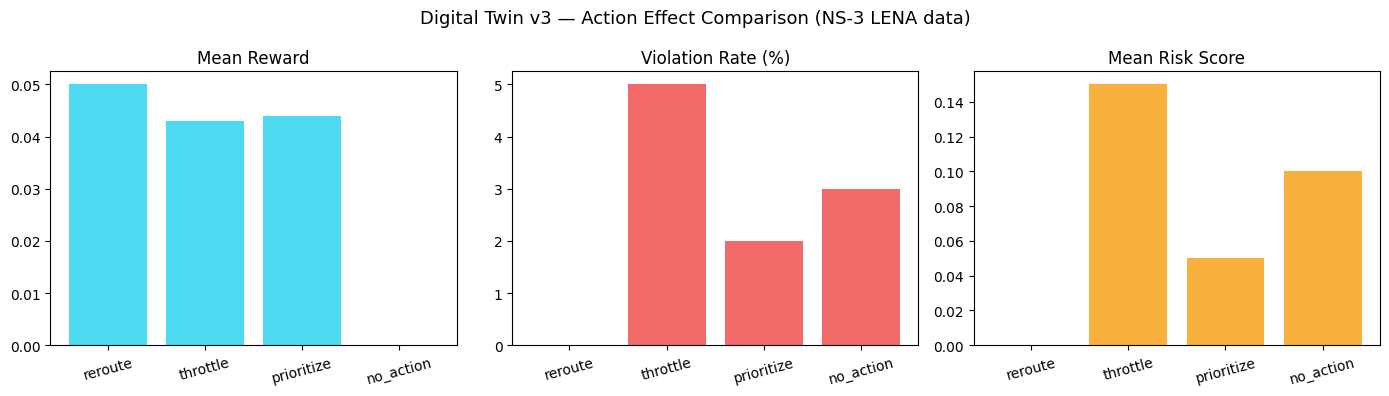

In [16]:
# --- 6. Action Comparison ---
print('Testing each action over 100 steps...')
os.makedirs('outputs', exist_ok=True)   # <-- Add this line

action_stats = {}
for action in range(4):
    obs, _ = env.reset()
    rewards, violations, risks = [], [], []
    for _ in range(100):
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
        violations.append(info['sla_violation'])
        risks.append(info['risk_score'])
        if terminated or truncated:
            obs, _ = env.reset()
    action_stats[QoSNetworkEnv.ACTION_NAMES[action]] = {
        'mean_reward':    round(float(np.mean(rewards)), 3),
        'violation_rate': round(float(np.mean(violations))*100, 1),
        'mean_risk':      round(float(np.mean(risks)), 2),
    }

df_actions = pd.DataFrame(action_stats).T
print(df_actions)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title, color in zip(axes,
    ['mean_reward','violation_rate','mean_risk'],
    ['Mean Reward','Violation Rate (%)','Mean Risk Score'],
    ['#22d3ee','#ef4444','#f59e0b']):
    ax.bar(df_actions.index, df_actions[metric].astype(float), color=color, alpha=0.8)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Digital Twin v3 — Action Effect Comparison (NS-3 LENA data)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/action_comparison_twin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Dataset Distributions

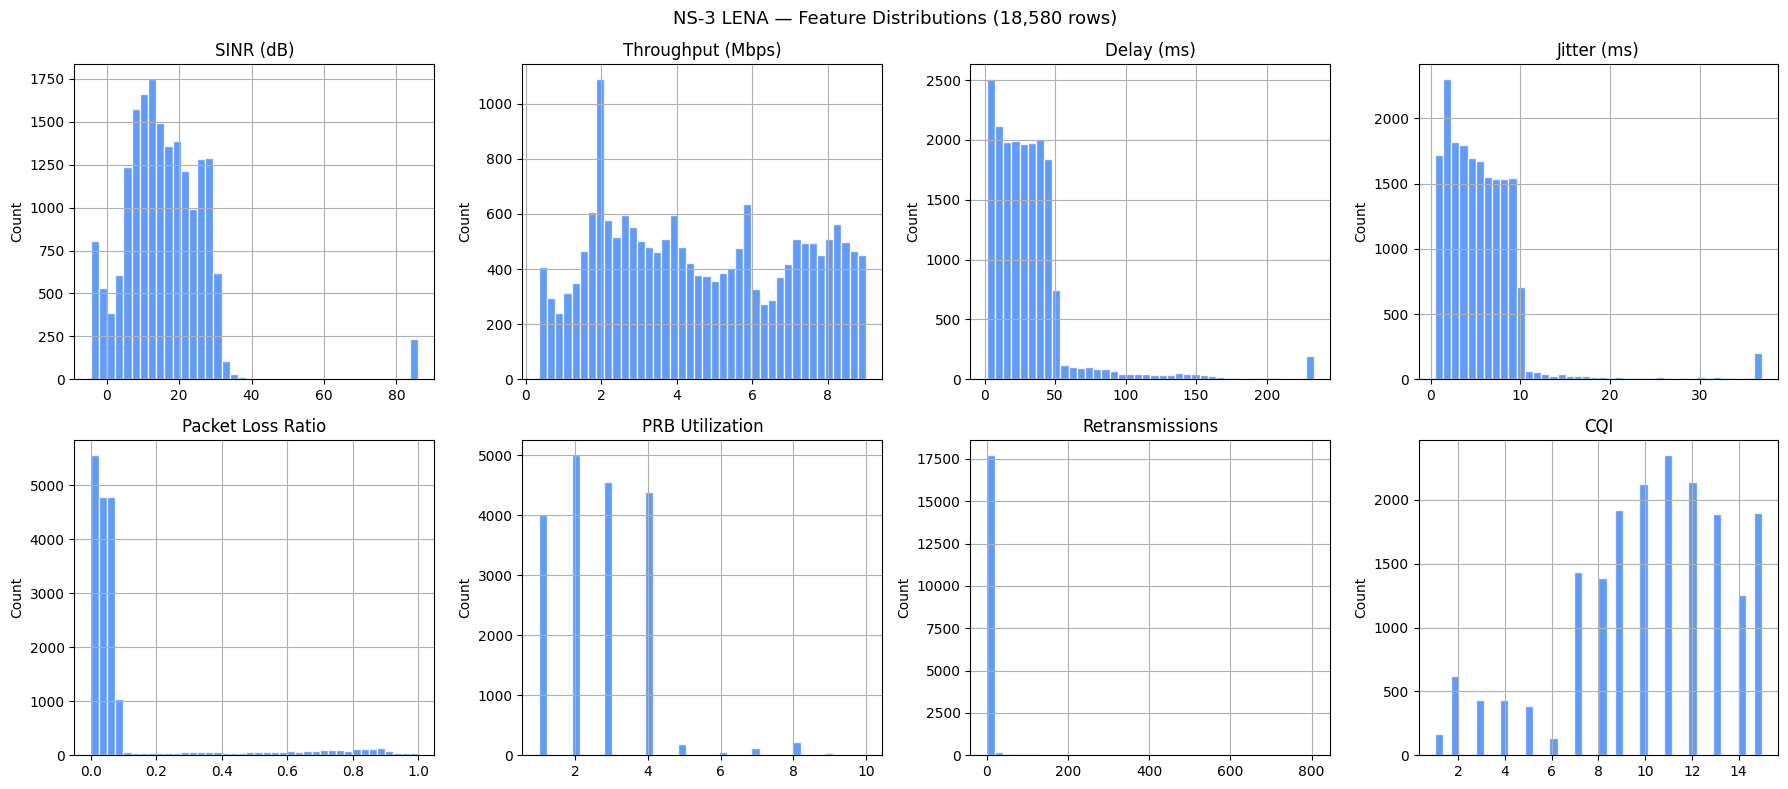

In [17]:
os.makedirs('outputs', exist_ok=True)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
ns3_cols = ['sinr_dl_db','throughput_mbps','delay_ms','jitter_ms',
            'packet_loss_ratio','prb_utilization','retransmissions','cqi']
titles   = ['SINR (dB)','Throughput (Mbps)','Delay (ms)','Jitter (ms)',
            'Packet Loss Ratio','PRB Utilization','Retransmissions','CQI']
for ax, col, title in zip(axes.flat, ns3_cols, titles):
    df[col].hist(bins=40, ax=ax, color='#3b82f6', alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.suptitle(f'NS-3 LENA — Feature Distributions ({len(df):,} rows)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/ns3_distributions_twin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Export → Handoff to M1

In [18]:
import shutil
output_dir = '/content/drive/MyDrive/QoSBuddy_DigitalTwin'
os.makedirs(output_dir, exist_ok=True)
os.makedirs('outputs', exist_ok=True)

shutil.copy('/content/QoSNetworkEnv.py', f'{output_dir}/QoSNetworkEnv.py')
print('Saved: QoSNetworkEnv.py -> Drive')

config = {
    'environment':        'QoSNetworkEnv',
    'version':            'v3_ns3_lena',
    'ns3_dataset':        '5g_dataset2.csv',
    'ns3_dataset_cols':   QoSNetworkEnv.OBS_COLS,
    'observation_space':  {
        'type': 'Box', 'shape': [8],
        'features': QoSNetworkEnv.OBS_COLS,
        'low':  QoSNetworkEnv.OBS_LOW.tolist(),
        'high': QoSNetworkEnv.OBS_HIGH.tolist(),
    },
    'action_space': {
        'type': 'Discrete', 'n': 4,
        'actions': {str(k): v for k, v in QoSNetworkEnv.ACTION_NAMES.items()}
    },
    'reward': {
        'formula':       '-1.0*violation + 0.3*risk_reduction + 0.05*proactive',
        'sla_thresholds': {str(k): v for k, v in QoSNetworkEnv.SLA.items()},
    },
    'episode_len': 50,
    'handoff_to':  'M1 (DSO3.1 PPO RL Agent)',
}

with open(f'{output_dir}/ns3_environment_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved: ns3_environment_config.json -> Drive')

df.to_csv(f'{output_dir}/lena_dataset_cleaned.csv', index=False)
print(f'Saved: lena_dataset_cleaned.csv -> Drive ({len(df):,} rows)')

print()
print('='*55)
print('  DIGITAL TWIN v3 — EXPORT SUMMARY')
print('='*55)
for fn in sorted(os.listdir(output_dir)):
    p  = f'{output_dir}/{fn}'
    sz = os.path.getsize(p) / 1024
    print(f'  {fn:<45} {sz:>7.1f} KB')
print('='*55)
print('  QoSNetworkEnv.py            -> M1 (PPO RL training)')
print('  ns3_environment_config.json -> M1 (env config)')
print('  lena_dataset_cleaned.csv    -> M1 + DSO2.1 reference')

Saved: QoSNetworkEnv.py -> Drive
Saved: ns3_environment_config.json -> Drive
Saved: lena_dataset_cleaned.csv -> Drive (18,580 rows)

  DIGITAL TWIN v3 — EXPORT SUMMARY
  QoSNetworkEnv.py                                  8.0 KB
  lena_dataset_cleaned.csv                       1113.2 KB
  ns3_environment_config.json                       1.5 KB
  QoSNetworkEnv.py            -> M1 (PPO RL training)
  ns3_environment_config.json -> M1 (env config)
  lena_dataset_cleaned.csv    -> M1 + DSO2.1 reference
